# Diabetes Prediction Practice

Notebook ini dibuat untuk latihan membangun model **Klasifikasi** untuk diagnosa diabetes.

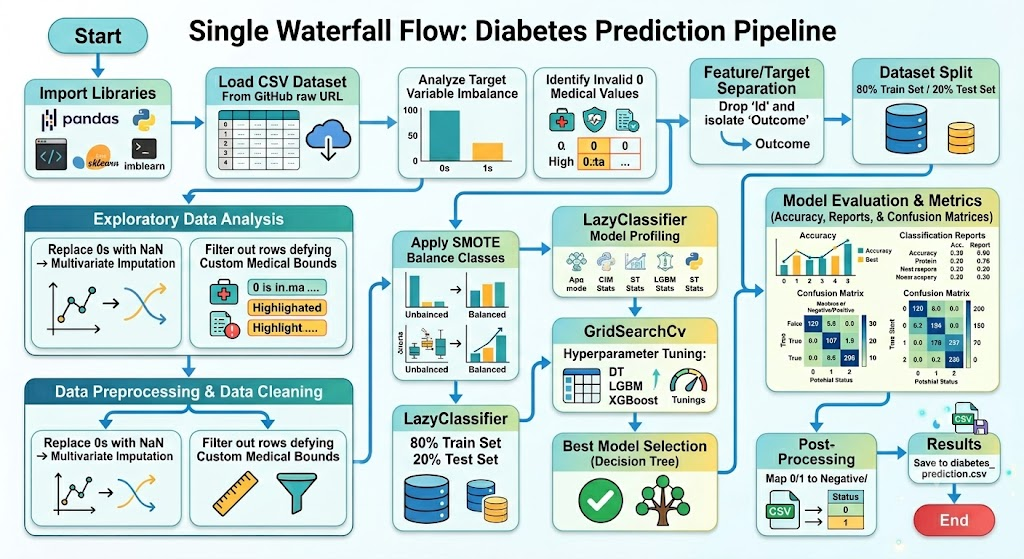


## 1. Import Library


In [1]:
# Install library pendukung jika belum tersedia
!pip install -q imbalanced-learn lazypredict

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.0/71.0 kB 5.3 MB/s eta 0:00:00


In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import AdaBoostClassifier, RandomForestClassifier, BaggingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, PrecisionRecallDisplay, ConfusionMatrixDisplay
from google.colab import files
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from imblearn.over_sampling import SMOTE
from sklearn.tree import DecisionTreeClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from lazypredict.Supervised import LazyClassifier


---

## 2. Data Understanding


### A. Memuat Dataset


In [3]:
# Define the filename
file_name = 'https://raw.githubusercontent.com/mpfordreamer/classification-practice/main/datasets/diabetes.csv'

# Load and display dataset
df = pd.read_csv(file_name)
print(f"Successfully loaded dataset. Displaying the first 5 rows:")
df.head()

Successfully loaded dataset. Displaying the first 5 rows:


,Id,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,1,6,148,72,35,0,33.6,0.627,50,1
1,2,1,85,66,29,0,26.6,0.351,31,0
2,3,8,183,64,0,0,23.3,0.672,32,1
3,4,1,89,66,23,94,28.1,0.167,21,0
4,5,0,137,40,35,168,43.1,2.288,33,1


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2768 entries, 0 to 2767
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Id                        2768 non-null   int64  
 1   Pregnancies               2768 non-null   int64  
 2   Glucose                   2768 non-null   int64  
 3   BloodPressure             2768 non-null   int64  
 4   SkinThickness             2768 non-null   int64  
 5   Insulin                   2768 non-null   int64  
 6   BMI                       2768 non-null   float64
 7   DiabetesPedigreeFunction  2768 non-null   float64
 8   Age                       2768 non-null   int64  
 9   Outcome                   2768 non-null   int64  
dtypes: float64(2), int64(8)
memory usage: 216.4 KB


In [5]:
df.describe()

,Id,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,2768.000000,2768.000000,2768.000000,2768.000000,2768.000000,2768.000000,2768.000000,2768.000000,2768.000000,2768.000000
mean,1384.500000,3.742775,121.102601,69.134393,20.824422,80.127890,32.137392,0.471193,33.132225,0.343931
std,799.197097,3.323801,32.036508,19.231438,16.059596,112.301933,8.076127,0.325669,11.777230,0.475104
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,692.750000,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.244000,24.000000,0.000000
50%,1384.500000,3.000000,117.000000,72.000000,23.000000,37.000000,32.200000,0.375000,29.000000,0.000000
75%,2076.250000,6.000000,141.000000,80.000000,32.000000,130.000000,36.625000,0.624000,40.000000,1.000000
max,2768.000000,17.000000,199.000000,122.000000,110.000000,846.000000,80.600000,2.420000,81.000000,1.000000


## 3. Analisis Data Eksploratif (EDA)


### A. Analisis Data Kategorikal



Distribution of Outcome:
Outcome
0    1816
1     952
Name: count, dtype: int64


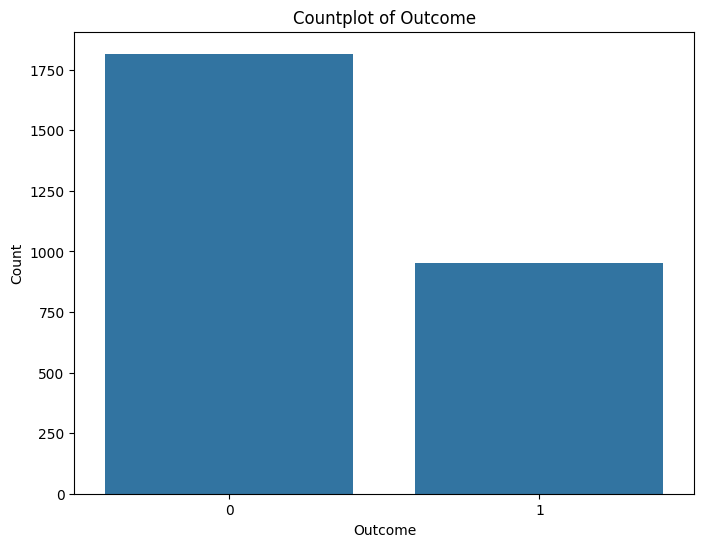


Columns in the dataset:
Index(['Id', 'Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
       'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')


In [6]:
# Check the distribution of the Outcome column
print("\nDistribution of Outcome:")
print(df['Outcome'].value_counts())

# Plot countplot for the Outcome column
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='Outcome')
plt.title('Countplot of Outcome')
plt.xlabel('Outcome')
plt.ylabel('Count')
plt.show()

# List all columns in the dataset
print("\nColumns in the dataset:")
print(df.columns)

*Melihat distribusi kelas target (Outcome).*


### B. Analisis Data Numerikal


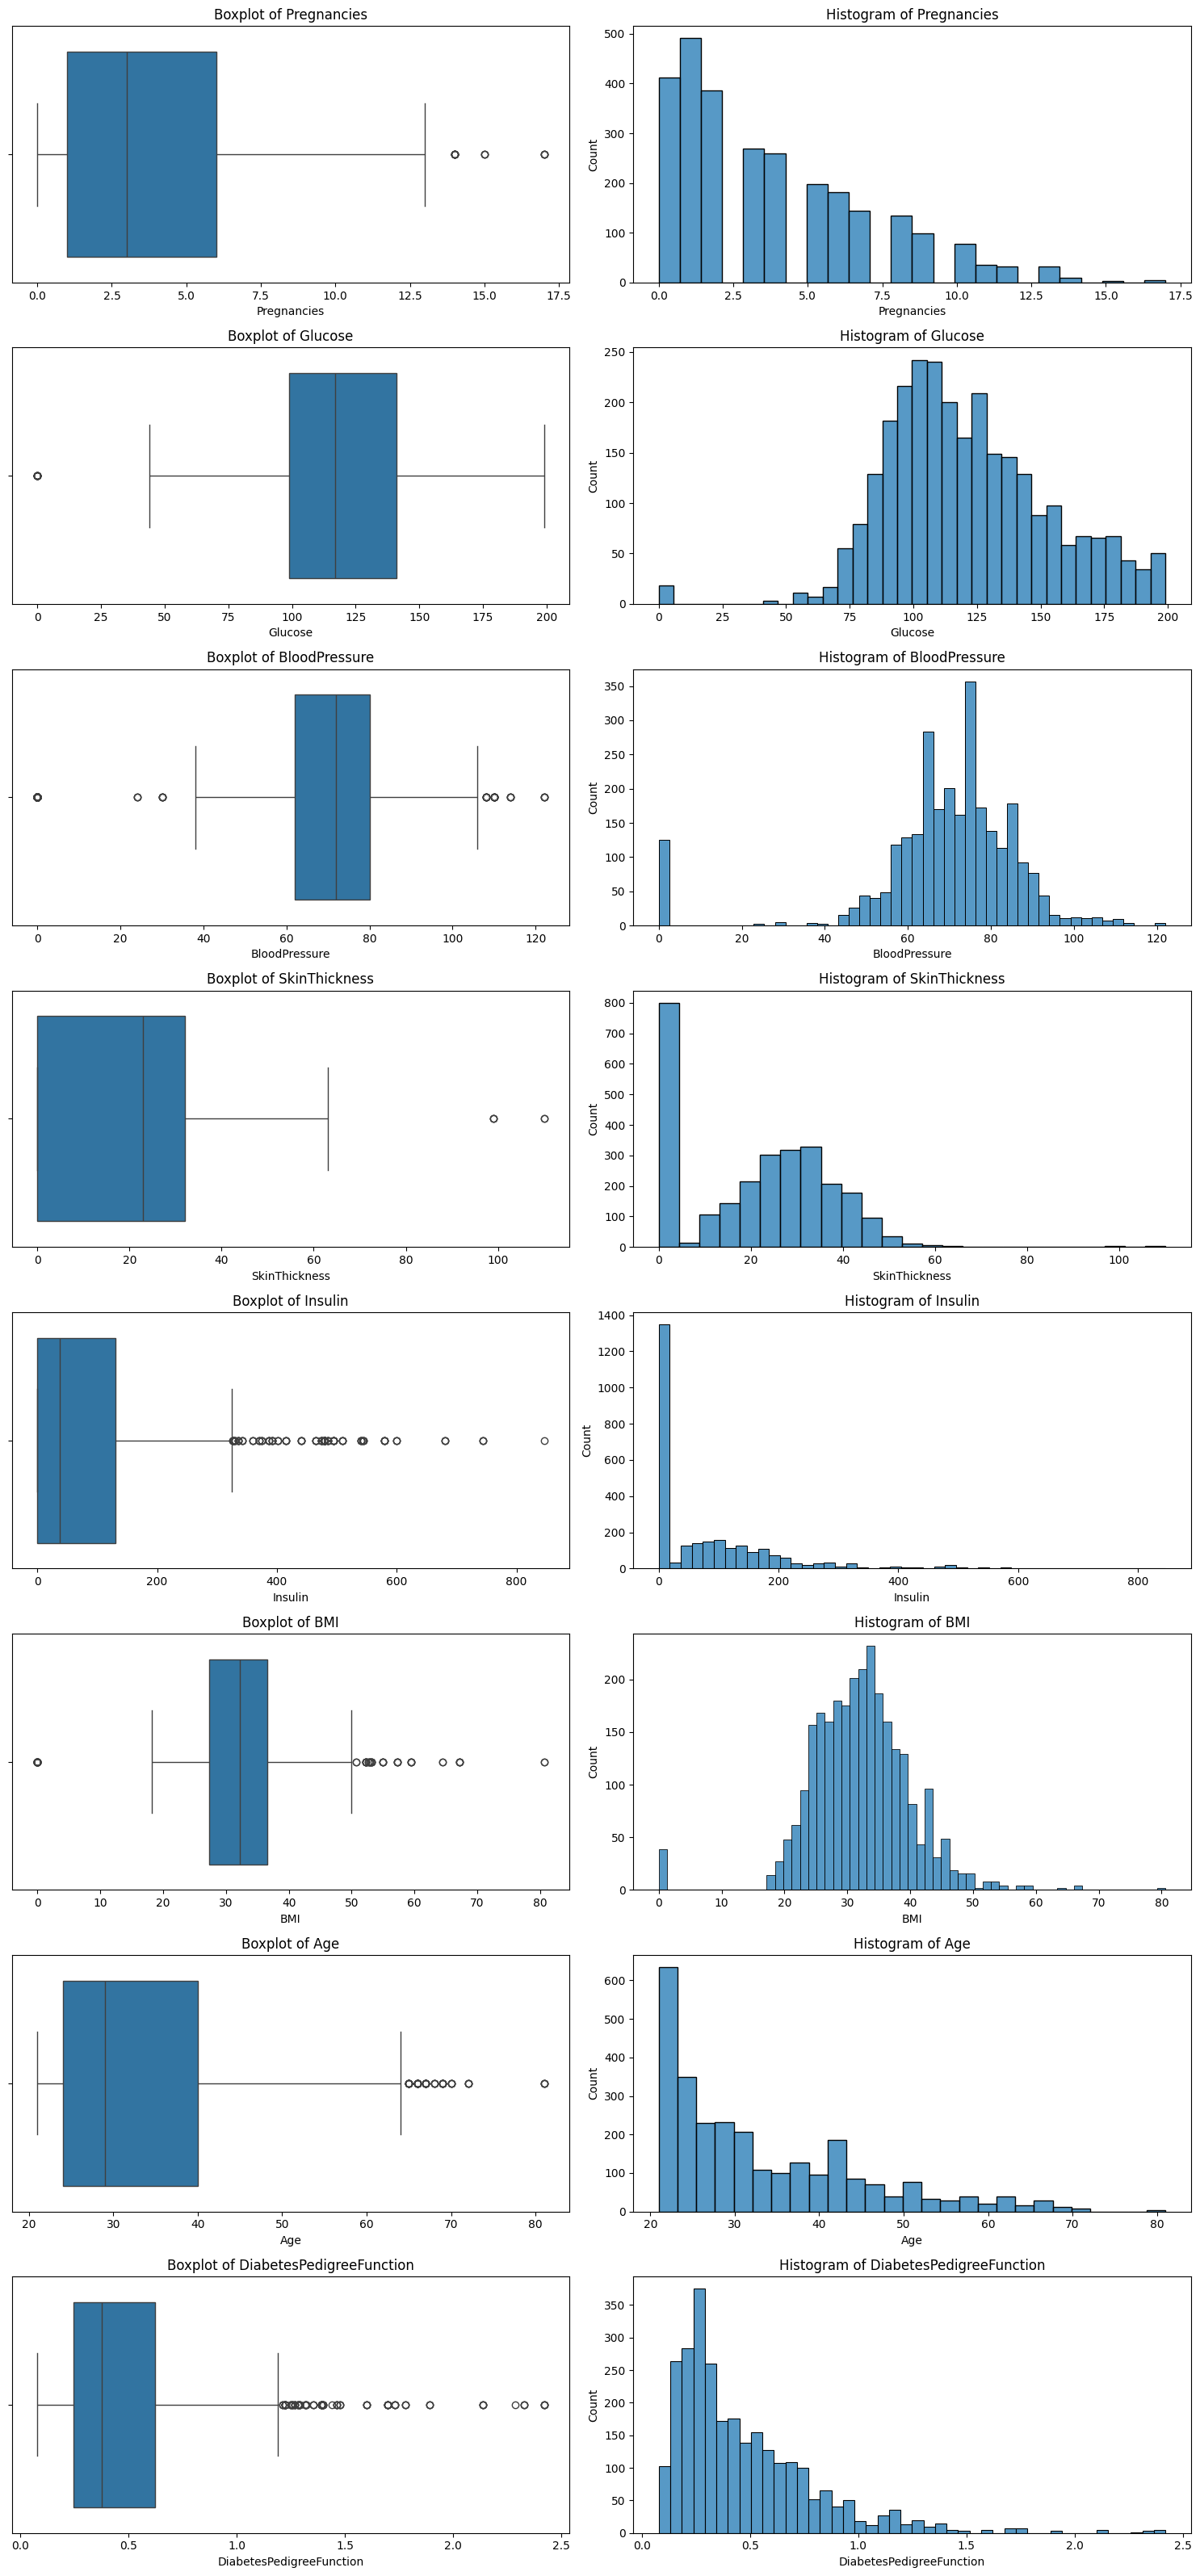

In [7]:
# Define columns to plot
columns_to_plot = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'Age', 'DiabetesPedigreeFunction']

# Create subplots for boxplots and histograms
num_cols = len(columns_to_plot)
fig, axes = plt.subplots(nrows=num_cols, ncols=2, figsize=(15, 4 * num_cols))

for i, column in enumerate(columns_to_plot):
    # Boxplot
    sns.boxplot(data=df, x=column, ax=axes[i, 0])
    axes[i, 0].set_title(f'Boxplot of {column}')
    axes[i, 0].set_xlabel(column)

    # Histogram
    sns.histplot(data=df[column], ax=axes[i, 1])
    axes[i, 1].set_title(f'Histogram of {column}')
    axes[i, 1].set_xlabel(column)
    axes[i, 1].set_ylabel('Count')

plt.tight_layout()
plt.show()

*Melihat distribusi dan boxplot untuk fitur numerik.*


## 4. Preprocessing Data


### A. Pembersihan Data (Cleaning)


In [8]:
print("\nJumlah Nilai 0 dalam Setiap Kolom:")
zero_counts = (df == 0).sum()
print(zero_counts)


Jumlah Nilai 0 dalam Setiap Kolom:
Id                             0
Pregnancies                  412
Glucose                       18
BloodPressure                125
SkinThickness                800
Insulin                     1330
BMI                           39
DiabetesPedigreeFunction       0
Age                            0
Outcome                     1816
dtype: int64


In [9]:
invalid_zero_columns = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
df[invalid_zero_columns] = df[invalid_zero_columns].replace(0, np.nan)

In [10]:
imputer = IterativeImputer(
    max_iter=10,
    random_state=42
)

df[invalid_zero_columns] = imputer.fit_transform(df[invalid_zero_columns])
print("\nJumlah Nilai Kosong Setelah Imputasi:")
print(df[invalid_zero_columns].isna().sum())


Jumlah Nilai Kosong Setelah Imputasi:
Glucose          0
BloodPressure    0
SkinThickness    0
Insulin          0
BMI              0
dtype: int64


In [11]:
# Checking for duplicates
duplicates = df.duplicated().sum()
print(f"\nJumlah Baris Duplikat: {duplicates}")

# Remove duplicate rows
df.drop_duplicates(inplace=True)

# Rechecking the number of duplicate rows
duplicates_after = df.duplicated().sum()
print(f"Jumlah Baris Duplikat Setelah Penghapusan: {duplicates_after}")


Jumlah Baris Duplikat: 0
Jumlah Baris Duplikat Setelah Penghapusan: 0


In [12]:
# Display the first few rows of the dataset after cleaning
print("\nData Setelah Cleaning:")
print(df.head())

# Save the cleaned dataset to a new file
df.to_csv('diabetes.csv', index=False)


Data Setelah Cleaning:
   Id  Pregnancies  Glucose  BloodPressure  SkinThickness     Insulin   BMI  \
0   1            6    148.0           72.0      35.000000  205.022513  33.6   
1   2            1     85.0           66.0      29.000000   67.233542  26.6   
2   3            8    183.0           64.0      21.617988  258.092332  23.3   
3   4            1     89.0           66.0      23.000000   94.000000  28.1   
4   5            0    137.0           40.0      35.000000  168.000000  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  


In [13]:
# Define custom bounds for realistic medical data
custom_bounds = {
    'BloodPressure': (0, 200),
    'SkinThickness': (0, 100),
    'Insulin': (0, 850),
    'BMI': (0, 70),
    'Age': (0, 100)
}

# Check and print outliers before removing them
df_clean = df.copy()

for col, (lower, upper) in custom_bounds.items():
    # Find rows outside the safe bounds
    outliers = df_clean[~df_clean[col].between(lower, upper)]
    print(f"Total outliers in {col}: {len(outliers)}")

    # Keep only rows within the safe bounds
    df_clean = df_clean[df_clean[col].between(lower, upper)]

# Verify the final result
print("\nFirst few rows after removing outliers:")
df_clean.head()

Total outliers in BloodPressure: 0
Total outliers in SkinThickness: 2
Total outliers in Insulin: 3
Total outliers in BMI: 2
Total outliers in Age: 0

First few rows after removing outliers:


,Id,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,1,6,148.0,72.0,35.000000,205.022513,33.6,0.627,50,1
1,2,1,85.0,66.0,29.000000,67.233542,26.6,0.351,31,0
2,3,8,183.0,64.0,21.617988,258.092332,23.3,0.672,32,1
3,4,1,89.0,66.0,23.000000,94.000000,28.1,0.167,21,0
4,5,0,137.0,40.0,35.000000,168.000000,43.1,2.288,33,1


### B. Explodatory Data Analysis

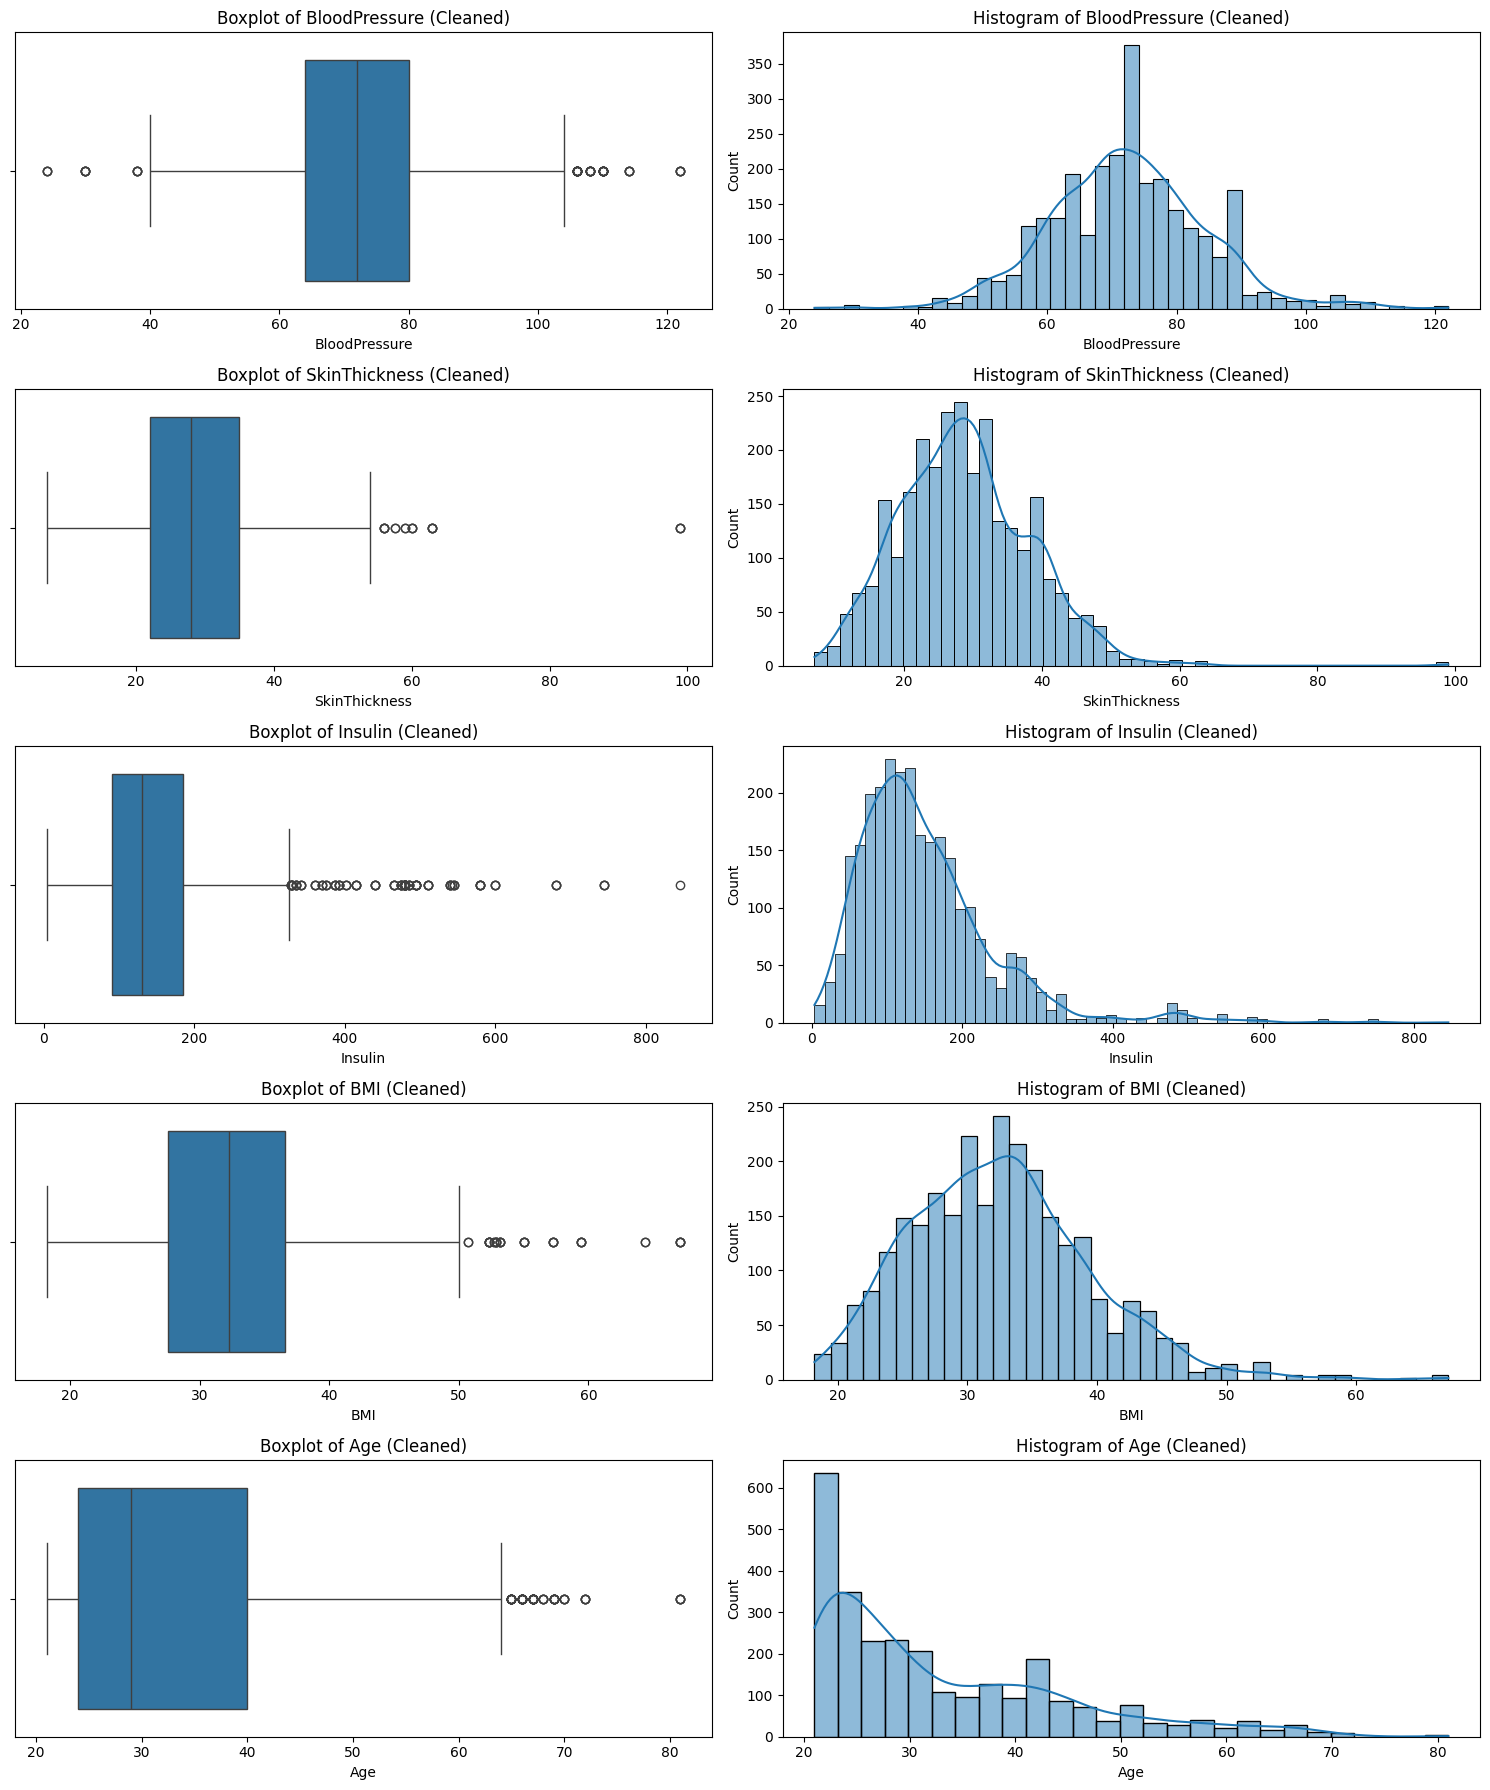

In [14]:
# Create a grid of subplots (5 rows, 2 columns)
fig, axes = plt.subplots(nrows=len(custom_bounds), ncols=2, figsize=(15, 18))

# Loop through each column and plot directly to the axes
for i, col in enumerate(custom_bounds.keys()):

    # Left column: Boxplot
    sns.boxplot(data=df_clean, x=col, ax=axes[i, 0])
    axes[i, 0].set_title(f'Boxplot of {col} (Cleaned)')

    # Right column: Histogram
    sns.histplot(data=df_clean, x=col, ax=axes[i, 1], kde=True)
    axes[i, 1].set_title(f'Histogram of {col} (Cleaned)')

# Adjust layout to prevent text overlapping
plt.tight_layout()
plt.show()

*Melihat distribusi setelah pembersihan outlier.*


Numerical Columns: Index(['Id', 'Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
       'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')


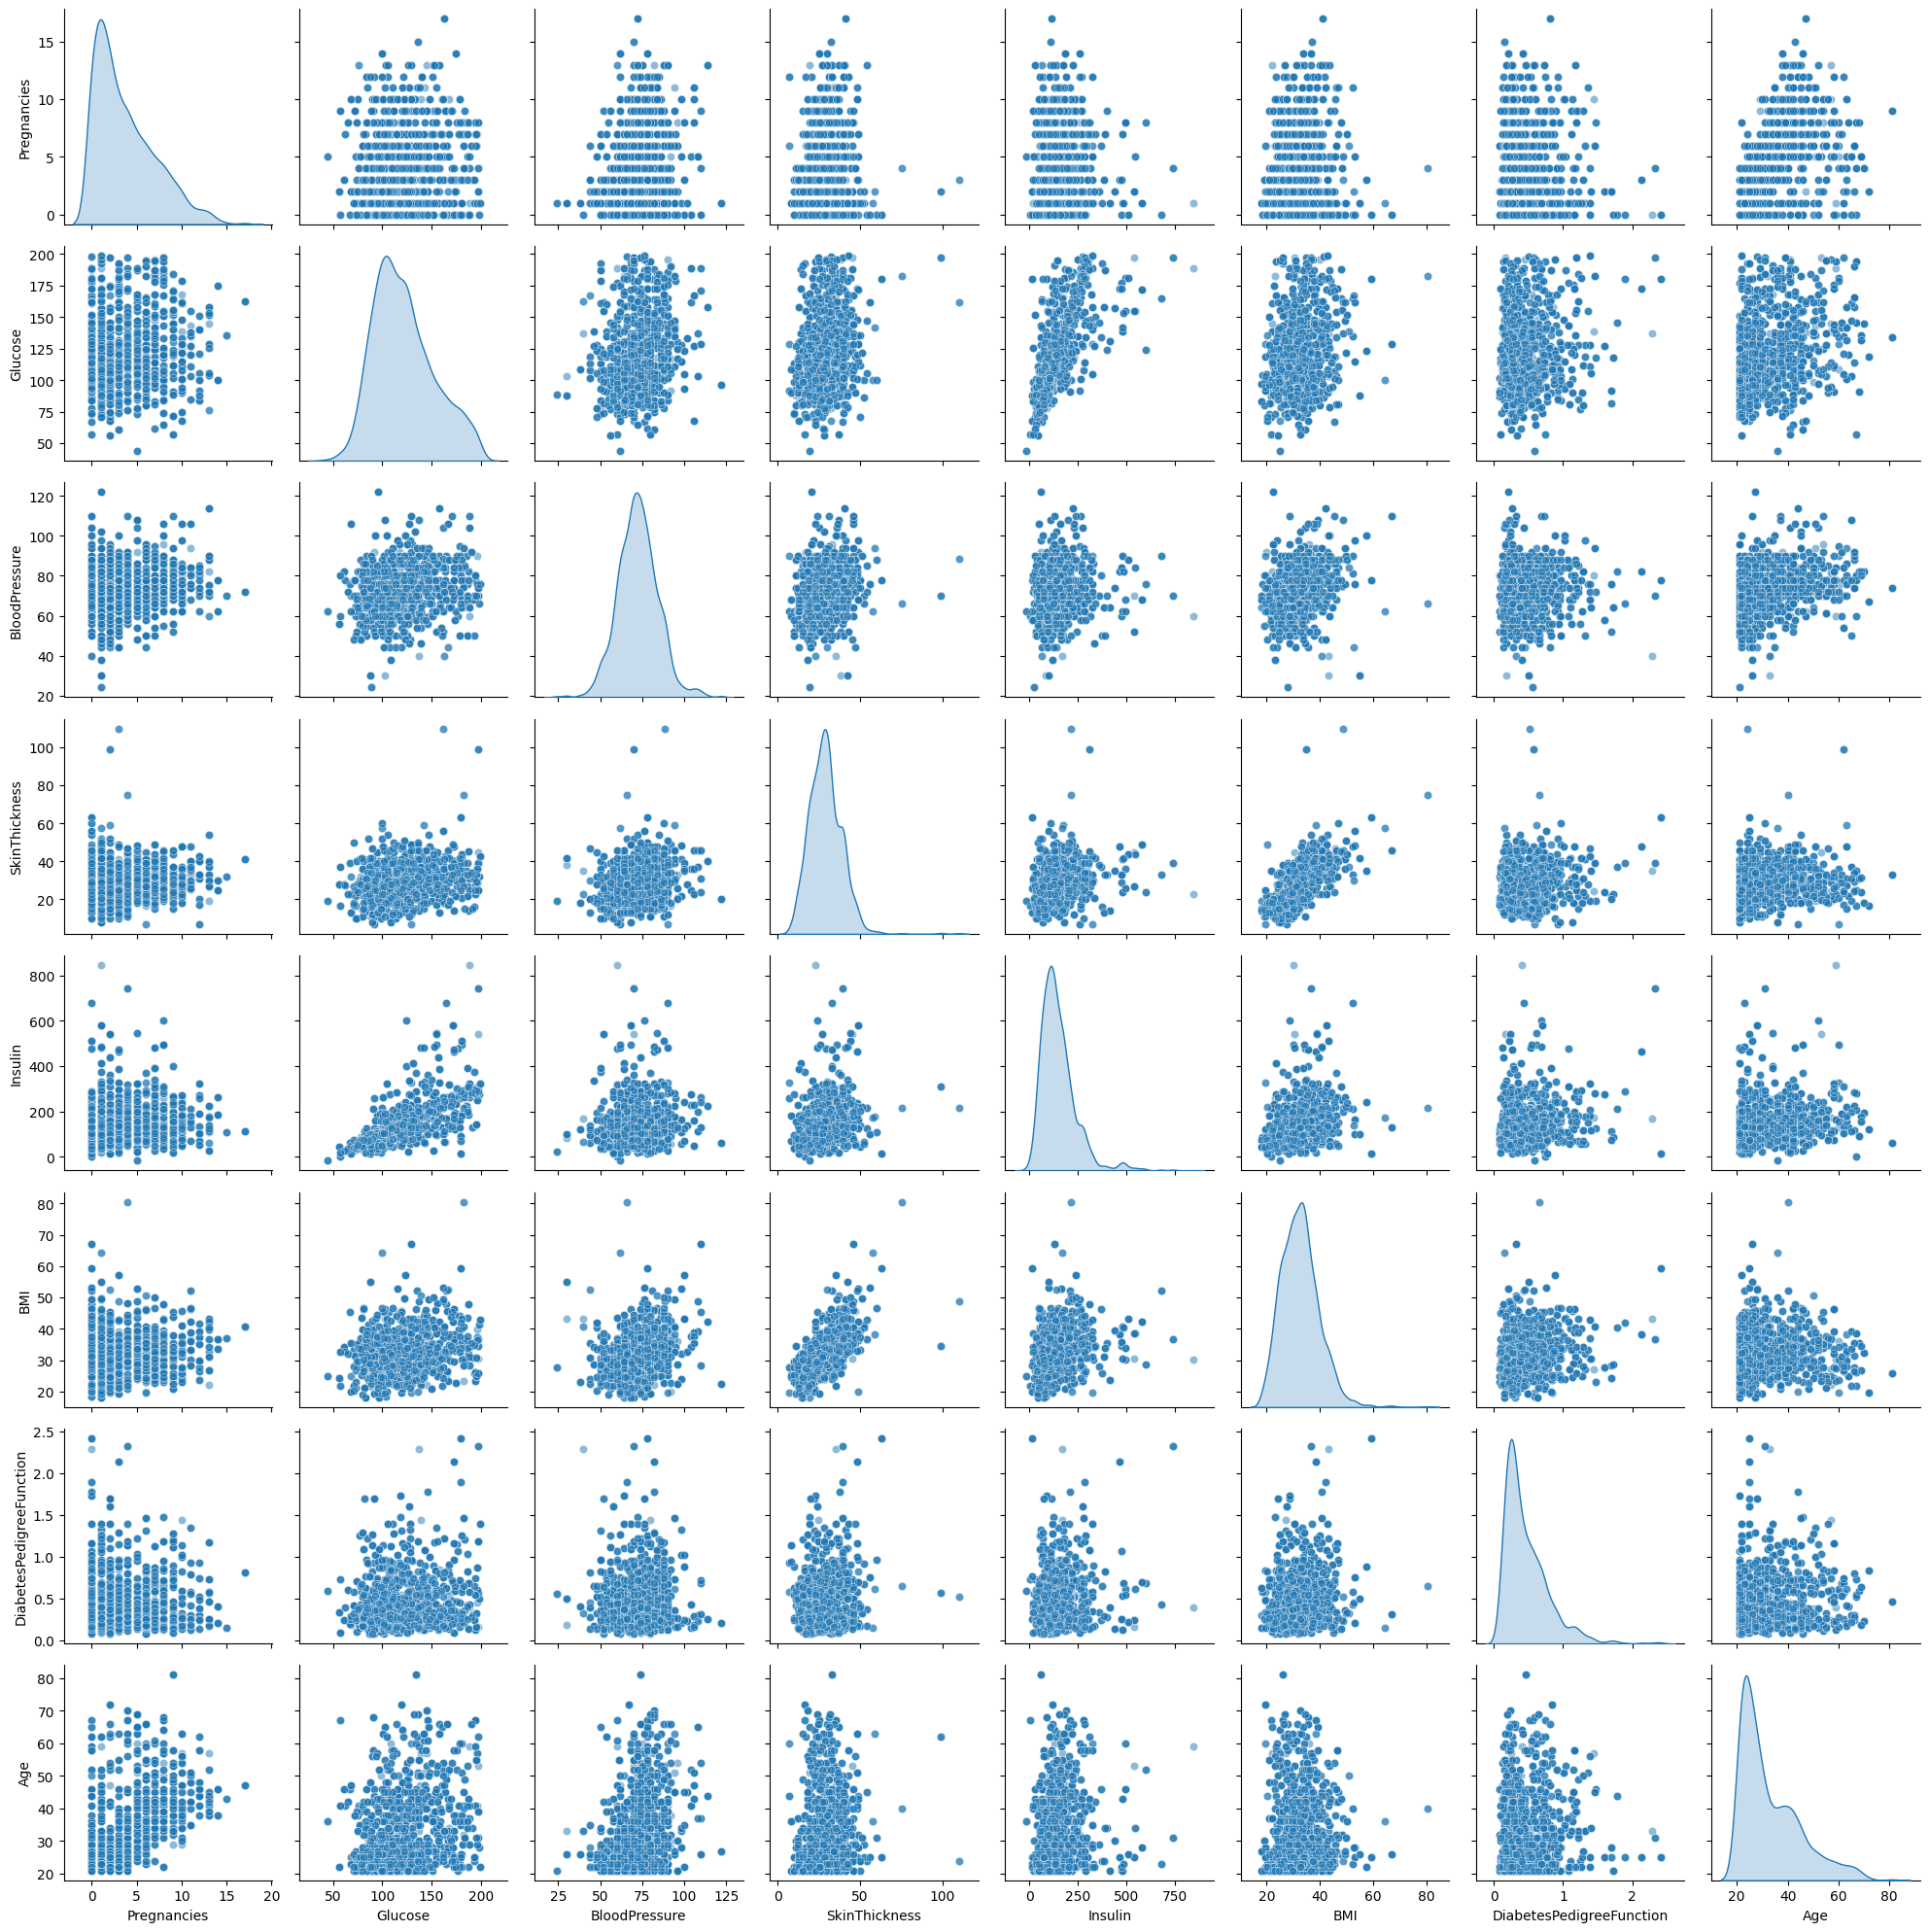

In [15]:
# Select only numerical columns
numerical_cols = df.select_dtypes(include=['number']).columns
print("Numerical Columns:", numerical_cols)

# Exclude the 'Outcome' and 'id' columns if they exist
numerical_cols = numerical_cols.drop('Outcome', errors='ignore')
numerical_cols = numerical_cols.drop('Id', errors='ignore')

# Create a pairplot for the numerical columns
sns.pairplot(
    df[numerical_cols],
    diag_kind='kde',
    plot_kws={'alpha': 0.5},
    height=2.5
)

# Adjust layout to prevent overlap
plt.tight_layout()

# Show the plot
plt.show()

*Melihat hubungan antar pasangan fitur numerik (Pairplot).*


Correlation Matrix:


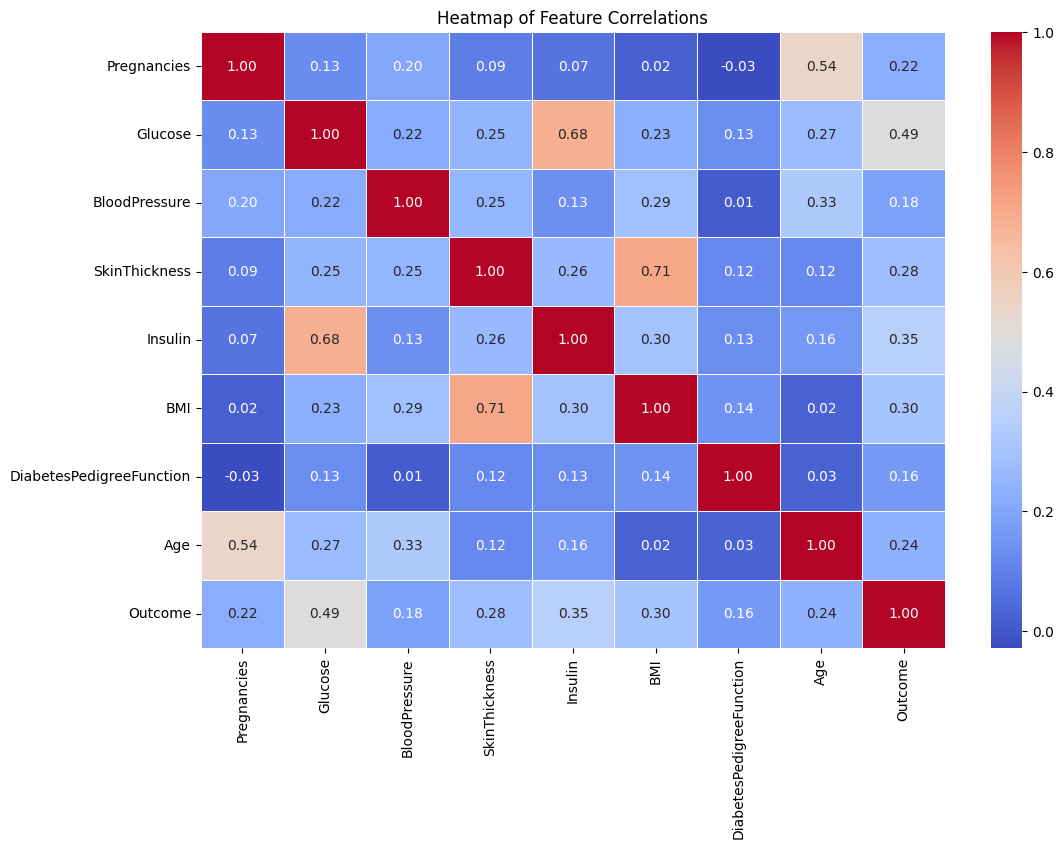

In [16]:
# Select only numerical columns and drop the 'Id' column if it exists
numerical_cols = df_clean.select_dtypes(include=['number']).columns
numerical_cols = numerical_cols.drop('Id', errors='ignore')

# Filter the DataFrame to include only the selected numerical columns
df_clean = df_clean[numerical_cols]

# Calculate the correlation matrix
corr_matrix = df_clean.corr()

# Display the correlation matrix
print("Correlation Matrix:")

# Plot the heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    linewidths=0.5
)
plt.title('Heatmap of Feature Correlations')
plt.show()

*Heatmap korelasi antar fitur numerik dan target.*


### B. Pembagian Dataset (Split)


In [17]:
# Separate features and target variable, dropping 'Id' if it exists
X = df_clean.drop(['Outcome', 'Id'], axis=1, errors='ignore')
y = df_clean['Outcome']

*Memisahkan fitur (X) dan target (y).*


In [18]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Display the shapes of the resulting datasets
print("\nShapes of the datasets:")
print(f"X_train: {X_train.shape}")
print(f"X_test: {X_test.shape}")
print(f"y_train: {y_train.shape}")
print(f"y_test: {y_test.shape}")


Shapes of the datasets:
X_train: (2208, 8)
X_test: (553, 8)
y_train: (2208,)
y_test: (553,)


### C. Penanganan Class Imbalance (SMOTE)


In [19]:
# SMOTE for balance 2 class
sm = SMOTE(random_state=42)
X_train, y_train = sm.fit_resample(X_train, y_train)

---

## 5. Pembangunan Model & Evaluasi


In [20]:
#Lazy Classifier Method for ML Comparison
clf = LazyClassifier(
    verbose=0,
    ignore_warnings=True,
    custom_metric=None
)
models, predictions = clf.fit(X_train, X_test, y_train, y_test)
print(models)

                               Accuracy  Balanced Accuracy   ROC AUC  \
Model                                                                  
DecisionTreeClassifier         1.000000           1.000000  1.000000   
LGBMClassifier                 0.998192           0.998674  0.999684   
XGBClassifier                  0.996383           0.997347  0.999910   
BaggingClassifier              0.994575           0.994507  0.999962   
ExtraTreeClassifier            0.990958           0.988825  0.988825   
ExtraTreesClassifier           0.990958           0.988825  0.999910   
RandomForestClassifier         0.989150           0.985984  0.999879   
LabelSpreading                 0.983725           0.978976  0.993459   
LabelPropagation               0.983725           0.978976  0.994529   
KNeighborsClassifier           0.869801           0.863614  0.956158   
NuSVC                          0.835443           0.830842  0.883907   
SVC                            0.837251           0.827624  0.89

*Memanfaatkan LazyPredict untuk estimasi awal model terbaik.*


In [21]:
# Define the models and respective hyperparameter grids
models = {
    'DecisionTree': {
        'model': DecisionTreeClassifier(),
        'params': {
            'criterion': ['gini', 'entropy'],
            'max_depth': [None, 10, 20, 30],
            'min_samples_split': [2, 5, 10],
            'min_samples_leaf': [1, 2, 4]
        }
    },
    'LGBM': {
        'model': LGBMClassifier(verbosity=-1),
        'params': {
            'n_estimators': [100, 200, 300],
            'max_depth': [3, 5, 7],
            'learning_rate': [0.01, 0.1, 0.2],
            'num_leaves': [20, 31, 40]
        }
    },
    'XGBoost': {
        'model': XGBClassifier(use_label_encoder=False, eval_metric='logloss', verbosity=0),
        'params': {
            'n_estimators': [100, 200, 300],
            'max_depth': [3, 5, 7],
            'learning_rate': [0.01, 0.1, 0.2],
            'subsample': [0.6, 0.8, 1.0]
        }
    }
}

### A. Pemilihan Model Terbaik menggunakan GridSearchCV


In [22]:
# Storage for the final best trained models
best_models = {}

# Train and evaluate each model configuration
for name, info in models.items():
    print(f"\n--- Tuning {name} ---")

    # Setup the grid search cross validation
    grid = GridSearchCV(
        estimator=info['model'],
        param_grid=info['params'],
        scoring='accuracy',
        cv=5
    )

    # Execute hyperparameter tuning on training data
    grid.fit(X_train, y_train)

    # Store the best estimator found
    best_models[name] = grid.best_estimator_
    print(f"Best Hyperparameters: {grid.best_params_}")

    # Evaluate the optimized model on test data
    y_pred = best_models[name].predict(X_test)

    # Display performance metrics
    print(f"Testing Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))


--- Tuning DecisionTree ---
Best Hyperparameters: {'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2}
Testing Accuracy: 0.9982

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       377
           1       1.00      0.99      1.00       176

    accuracy                           1.00       553
   macro avg       1.00      1.00      1.00       553
weighted avg       1.00      1.00      1.00       553

Confusion Matrix:
[[377   0]
 [  1 175]]

--- Tuning LGBM ---
Best Hyperparameters: {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 300, 'num_leaves': 40}
Testing Accuracy: 0.9928

Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       377
           1       0.99      0.98      0.99       176

    accuracy                           0.99       553
   macro avg       0.99      0.99      0.99       553

### B. Metrik Evaluasi


/tmp/ipykernel_5071/4036978361.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=model_names, y=test_scores, palette='coolwarm')


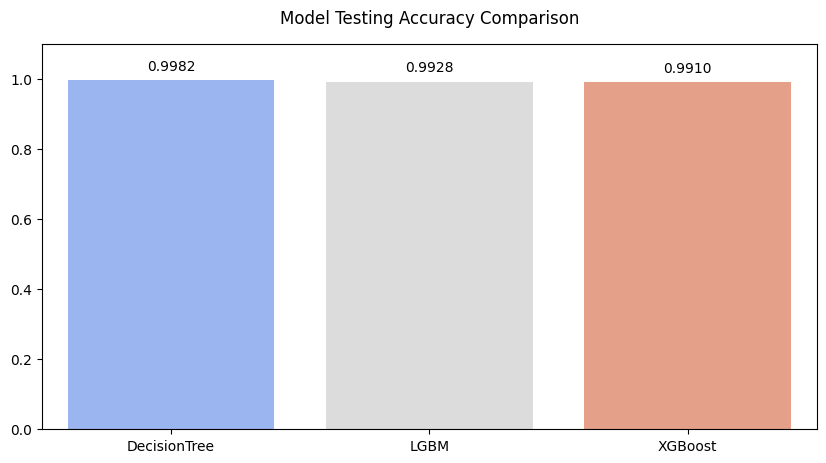


=================== DecisionTree Evaluation ===================


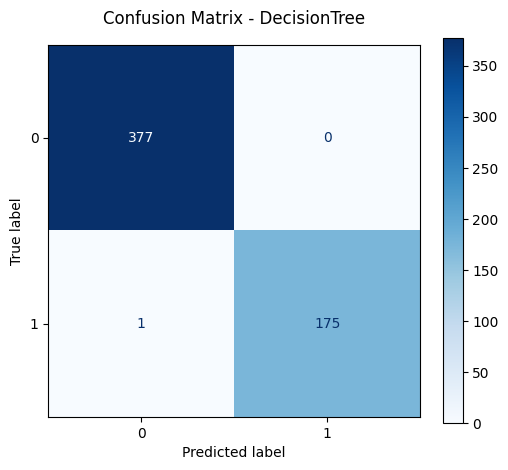

Metrics Breakdowns -> TN: 377, FP: 0, FN: 1, TP: 175
Error Diagnostic   -> Higher False Negatives (Type II error)


=================== LGBM Evaluation ===================


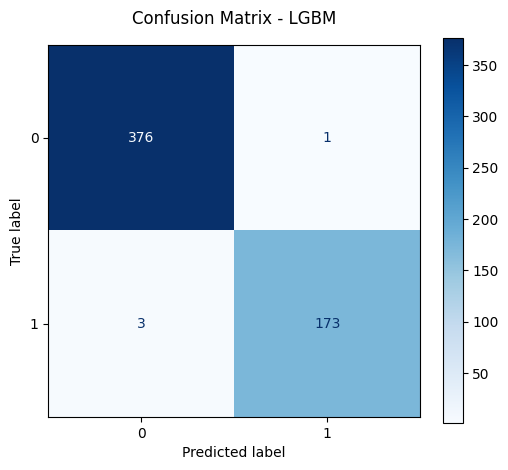

Metrics Breakdowns -> TN: 376, FP: 1, FN: 3, TP: 173
Error Diagnostic   -> Higher False Negatives (Type II error)


=================== XGBoost Evaluation ===================


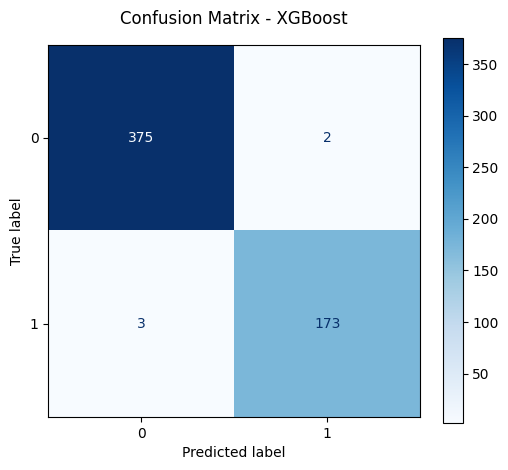

Metrics Breakdowns -> TN: 375, FP: 2, FN: 3, TP: 173
Error Diagnostic   -> Higher False Negatives (Type II error)



In [23]:
# Extract metrics directly from the best_models dictionary
model_names = list(best_models.keys())
test_scores = [accuracy_score(y_test, best_models[name].predict(X_test)) for name in model_names]

# Create a simple performance comparison bar chart
plt.figure(figsize=(10, 5))
ax = sns.barplot(x=model_names, y=test_scores, palette='coolwarm')
plt.ylim(0, 1.1)
plt.title('Model Testing Accuracy Comparison', fontsize=12, pad=15)

# Add text values on top of each bar
for p in ax.patches:
    ax.annotate(f'{p.get_height():.4f}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', xytext=(0, 5), textcoords='offset points')
plt.show()

# Generate evaluation charts for each trained model
for name, model in best_models.items():
    print(f"\n=================== {name} Evaluation ===================")
    y_pred = model.predict(X_test)

    # Plot standard confusion matrix using scikit-learn display layout
    fig, ax = plt.subplots(figsize=(6, 5))
    ConfusionMatrixDisplay.from_estimator(model, X_test, y_test, cmap='Blues', ax=ax)
    plt.title(f'Confusion Matrix - {name}', pad=15)
    plt.show()

    # Calculate automated textual insights based on confusion matrix results
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    if fp > fn:
        insight = 'Higher False Positives (Type I error)'
    elif fn > fp:
        insight = 'Higher False Negatives (Type II error)'
    else:
        insight = 'Balanced prediction errors'

    print(f"Metrics Breakdowns -> TN: {tn}, FP: {fp}, FN: {fn}, TP: {tp}")
    print(f"Error Diagnostic   -> {insight}\n")

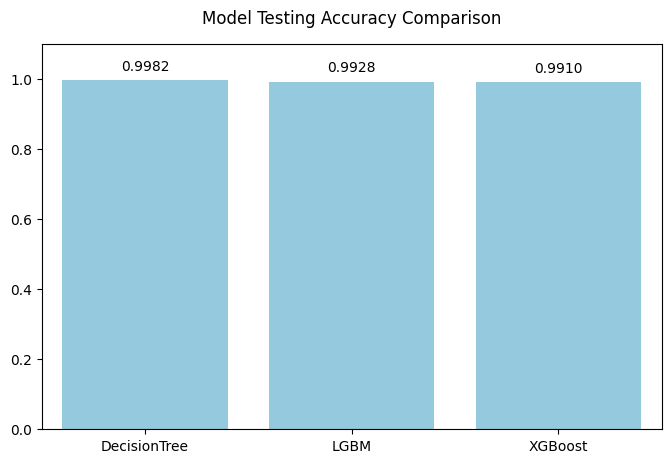

In [24]:
# Extract model names and compute their test accuracies
model_names = list(best_models.keys())
test_scores = [accuracy_score(y_test, best_models[name].predict(X_test)) for name in model_names]

# Create a clean bar chart for model comparison
plt.figure(figsize=(8, 5))
ax = sns.barplot(x=model_names, y=test_scores, color='skyblue')
plt.ylim(0, 1.1)
plt.title('Model Testing Accuracy Comparison', pad=15)

# Add exact accuracy values on top of each bar
for p in ax.patches:
    ax.annotate(f'{p.get_height():.4f}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', xytext=(0, 5), textcoords='offset points')

plt.show()

## Simpan Hasil Klasifikasi

In [25]:
# get the best model based on your conclusion
final_model = best_models['DecisionTree']

# generate predictions using the test data
predictions = final_model.predict(X_test)

# create a copy of the test data to store the results
results_dataframe = X_test.copy()

# add actual outcomes and the new predicted outcomes to the dataframe
results_dataframe['Actual_Outcome'] = y_test
results_dataframe['Predicted_Outcome'] = predictions

# define the text labels for the outcomes
outcome_labels = {0: 'Negative', 1: 'Positive'}

# replace numeric values with words for both outcome columns
results_dataframe['Actual_Outcome'] = results_dataframe['Actual_Outcome'].map(outcome_labels)
results_dataframe['Predicted_Outcome'] = results_dataframe['Predicted_Outcome'].map(outcome_labels)

In [26]:
# save the results to a comma separated values file
results_dataframe.to_csv('diabetes_prediction.csv', index=False)

# display the first few rows to verify the data
print("Prediction results successfully saved. Here is a preview:")
print(results_dataframe.head())

Prediction results successfully saved. Here is a preview:
      Pregnancies  Glucose  BloodPressure  SkinThickness     Insulin  \
368             3     81.0      86.000000      16.000000   66.000000   
2766            0    129.0     110.000000      46.000000  130.000000   
1332            0     91.0      80.000000      28.131800   85.099298   
2757            4    110.0      66.000000      27.700799  127.478274   
522             6    114.0      71.722816      28.253923  133.889462   

            BMI  DiabetesPedigreeFunction  Age Actual_Outcome  \
368   27.500000                     0.306   22       Negative   
2766  67.100000                     0.319   26       Positive   
1332  32.400000                     0.601   27       Negative   
2757  31.900000                     0.471   29       Negative   
522   32.159406                     0.189   26       Negative   

     Predicted_Outcome  
368           Negative  
2766          Positive  
1332          Negative  
2757          Nega